# Quality control: Segmentation metrics

**Duration** ~40 min &nbsp;·&nbsp; **Session** Day 2, Python notebooks

So far every judgement has been "look at the picture, does it seem right?".
That works until two results look similarly plausible, or until a reviewer asks
how that judgement was reached.

This notebook replaces squinting with numbers, and shows that the obvious
number is not enough.

**This notebook covers**

- computing IoU and Dice, and how they differ
- why pixel-level scores can be badly misleading
- matching objects between a result and a ground truth
- reporting precision, recall and F1 for a segmentation

**Data**: `data/bbbc020/`, plus the Weka export from the Fiji practical.

## 1. What is a ground truth?

A **ground truth** is a reference segmentation against which we compare a computed segmentation.

For a teaching example, we can make a tiny ground truth ourselves. This makes the metric formulas easier to understand before we work with real microscopy images.


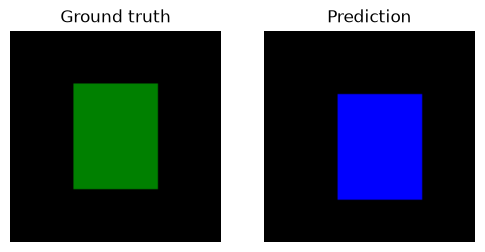

In [1]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import os; os.environ["DISPLAY"] = ":1"

from skimage.measure import label
from skimage.color import label2rgb

from course import DATA, show

from iaf.plot import imshow, show_labels
   
# A small synthetic ground-truth object
gt = np.zeros((100, 100), dtype=bool)
gt[25:75, 30:70] = True

# A slightly different prediction
prediction = np.zeros_like(gt)
prediction[30:80, 35:75] = True

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
show(label2rgb(gt, colors=['green']), ax=ax[0], title="Ground truth")
show(label2rgb(prediction, colors=['blue']), ax=ax[1], title="Prediction")

## 2. The two pixel scores

In computer vision two of the statistical metrics used to measure the overlap between a predicted region and the ground-truth region are:

#### Intersection over Union (IoU)

Strict penalty for mismatches; scales linearly with error. Commonly used for object detection and semantic segmentation

$$\text{IoU} = \frac{|A \cap B|}{|A \cup B|} $$

* $\cap$ (intersection): The pixels that are present in both A **and** B.
* $\cup$ (union): The pixels that are present in A **or** B **or** in both.

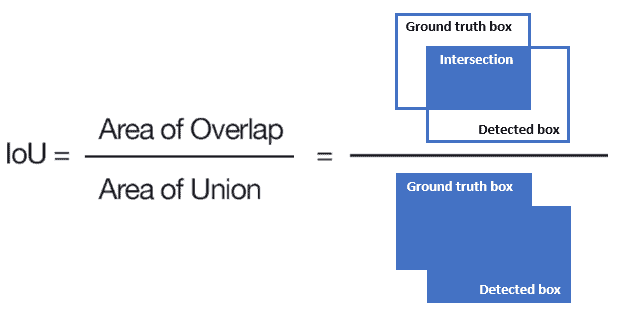

IoU is also called the **Jaccard index**: same formula, different name,
depending on the field.

#### Dice

Equivalates to the F1-score; weights the intersection more heavily, yielding higher scores for partial matches. Commonly used in medical image segmentation and fine pixel-level mask evaluations.

$$ \text{Dice} = \frac{2|A \cap B|}{|A| + |B|}$$



Both compare a predicted mask with a reference, and both are built from the same
two quantities: the pixels they **share**, and the pixels either one covers.





They always agree on ordering (if one says a result is better, so does the
other), but Dice is always the larger number for an imperfect overlap. Quoting
Dice therefore flatters a result slightly, which is worth knowing when reading
someone else's paper.

Now lets implement the two metrics and test it on _in silico_ data.

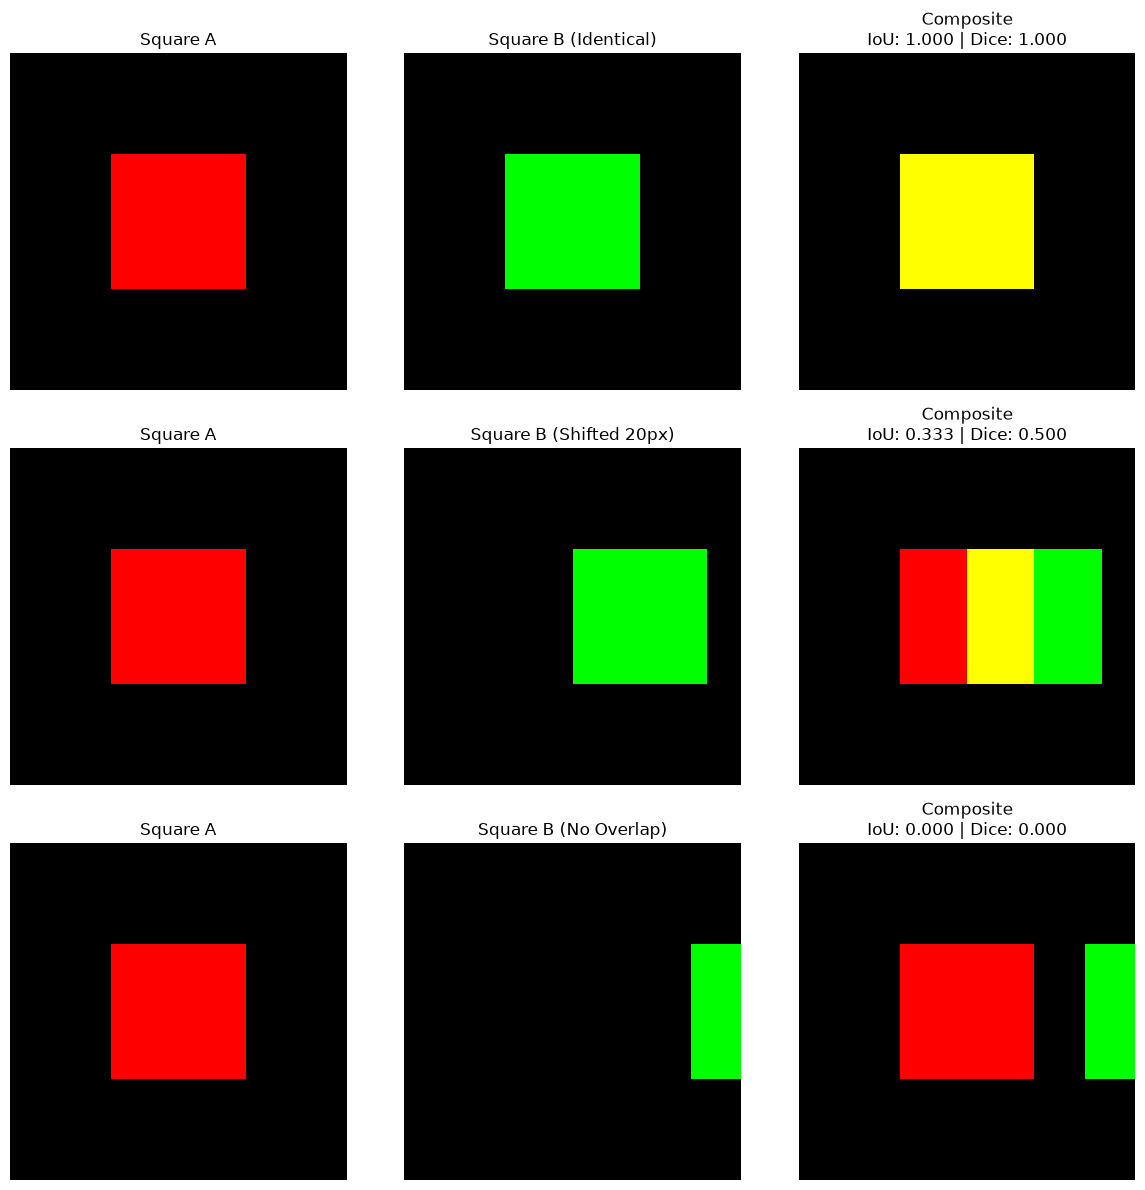

In [4]:
def iou(a, b):
    """Intersection over union of two masks (or label images)."""
    a, b = a > 0, b > 0
    union = (a | b).sum()
    return (a & b).sum() / union if union else 0.0


def dice(a, b):
    """Dice coefficient of two masks."""
    a, b = a > 0, b > 0
    total = a.sum() + b.sum()
    return 2 * (a & b).sum() / total if total else 0.0
    
# A quick sanity check on shapes we can reason about by hand.
def make_single_rgb(mask, color='red'):
    """Creates RGB image for a single mask (red or green)"""
    rgb = np.zeros((mask.shape[0], mask.shape[1], 3))
    if color == 'red':
        rgb[..., 0] = mask
    elif color == 'green':
        rgb[..., 1] = mask
    return rgb

def make_composite_rgb(mask_a, mask_b):
    """Combines A (red) and B (green). Overlapp turns yellow."""
    rgb = np.zeros((mask_a.shape[0], mask_a.shape[1], 3))
    rgb[..., 0] = mask_a  
    rgb[..., 1] = mask_b
    return rgb

grid_size = 100
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
sq_A = np.zeros((grid_size, grid_size), dtype=bool)
sq_A[30:70, 30:70] = True
sq_B1 = sq_A.copy()
sq_B2 = np.zeros((grid_size, grid_size), dtype=bool)
sq_B2[30:70, 50:90] = True
sq_B3 = np.zeros((grid_size, grid_size), dtype=bool)
sq_B3[30:70, 85:100] = True  

axs[0, 0].imshow(make_single_rgb(sq_A, 'red'))
axs[0, 0].set_title("Square A")
axs[0, 1].imshow(make_single_rgb(sq_B1, 'green'))
axs[0, 1].set_title("Square B (Identical)")
axs[0, 2].imshow(make_composite_rgb(sq_A, sq_B1))
axs[0, 2].set_title(f"Composite\nIoU: {iou(sq_A, sq_B1):.3f} | Dice: {dice(sq_A, sq_B1):.3f}")

axs[1, 0].imshow(make_single_rgb(sq_A, 'red'))
axs[1, 0].set_title("Square A")
axs[1, 1].imshow(make_single_rgb(sq_B2, 'green'))
axs[1, 1].set_title("Square B (Shifted 20px)")
axs[1, 2].imshow(make_composite_rgb(sq_A, sq_B2))
axs[1, 2].set_title(f"Composite\nIoU: {iou(sq_A, sq_B2):.3f} | Dice: {dice(sq_A, sq_B2):.3f}")

axs[2, 0].imshow(make_single_rgb(sq_A, 'red'))
axs[2, 0].set_title("Square A")
axs[2, 1].imshow(make_single_rgb(sq_B3, 'green'))
axs[2, 1].set_title("Square B (No Overlap)")
axs[2, 2].imshow(make_composite_rgb(sq_A, sq_B3))
axs[2, 2].set_title(f"Composite\nIoU: {iou(sq_A, sq_B3):.3f} | Dice: {dice(sq_A, sq_B3):.3f}")

for ax in axs.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

The half-overlapping case is the one to remember: the two squares share exactly
half their area, and IoU says 0.33 while Dice says 0.50. Same picture, two
different numbers, so the one used should always be stated.

## 3. Scoring the three segementation algorithms

To test how "good" our segmentation algorithms and efforts were so far we can compare it to a ground truth using the metrics we just learned.

We will compare, **simple thresholding**, **WEKA**, **WEKA with watershed** and **cellpose** segmentation results to a ground truth.

In [13]:
from skimage.filters import threshold_otsu, gaussian
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from skimage.color import rgb2gray
from cellpose import models

FIELD = "24h_2"
image = rgb2gray(tifffile.imread(DATA / "bbbc020" / "images" / f"jw-24h 2_c1.tif"))
truth = tifffile.imread(DATA / "bbbc020" / "gt" / f"jw-24h 2_c1 [1].tif")

# 1. yesterday's threshold pipeline
smoothed = gaussian(image, sigma=1, preserve_range=True)
mask = binary_fill_holes(smoothed > threshold_otsu(smoothed))
threshold_labels = label(remove_small_objects(mask, max_size=100))

# 2. yesterday's Weka classifier (class 1 is 'cell'; checked in notebook 03),
#    both as it comes (semantic) and after the watershed from notebook 03.
weka_mask = tifffile.imread(DATA / "bbbc020" / "weka" / "jw-24 2_c1_classified.tif") == 1
weka_labels = label(weka_mask)

from scipy.ndimage import distance_transform_edt
from skimage.segmentation import watershed

weka_distance = distance_transform_edt(weka_mask)
weka_instances = watershed(-weka_distance, label(weka_distance > 10), mask=weka_mask)

# 3. Cellpose
cellpose_labels, _, _, _ = models.Cellpose(model_type="cyto", gpu=False).eval(
    image, diameter=None, channels=[0, 0]
)

results = {
    "threshold": threshold_labels,
    "Weka": weka_labels,
    "Weka+watershed": weka_instances,
    "Cellpose": cellpose_labels,
}

In [14]:
print(f"{'method':16s} {'IoU':>7s} {'Dice':>7s} {'objects':>9s}   (truth: {len(np.unique(truth))})")
print("-" * 44)
for name, result in results.items():
    print(f"{name:16s} {iou(result, truth):7.3f} {dice(result, truth):7.3f} {result.max():9d}")

method               IoU    Dice   objects   (truth: 34)
--------------------------------------------
threshold          0.506   0.672        39
Weka               0.905   0.950        45
Weka+watershed     0.904   0.950        66
Cellpose           0.915   0.955        42


By pixel score the ranking is clear: Cellpose, then Weka, then the threshold.

Now look at the object counts beside those scores. **Weka scores a Dice of 0.94
, within a whisker of Cellpose, while producing 307 objects for
38 actual cells.** For an experiment that counts cells, those two methods are
not remotely comparable. The **pixel score** cannot see the difference, because
it never asks how the pixels are grouped.

In [18]:
np.unique(truth)

array([  0,   7,  13,  20,  27,  34,  40,  47,  54,  61,  67,  74,  81,
        88,  94, 101, 108, 115, 121, 128, 135, 141, 148, 155, 162, 182,
       189, 195, 202, 209, 236, 243, 249, 255], dtype=uint8)

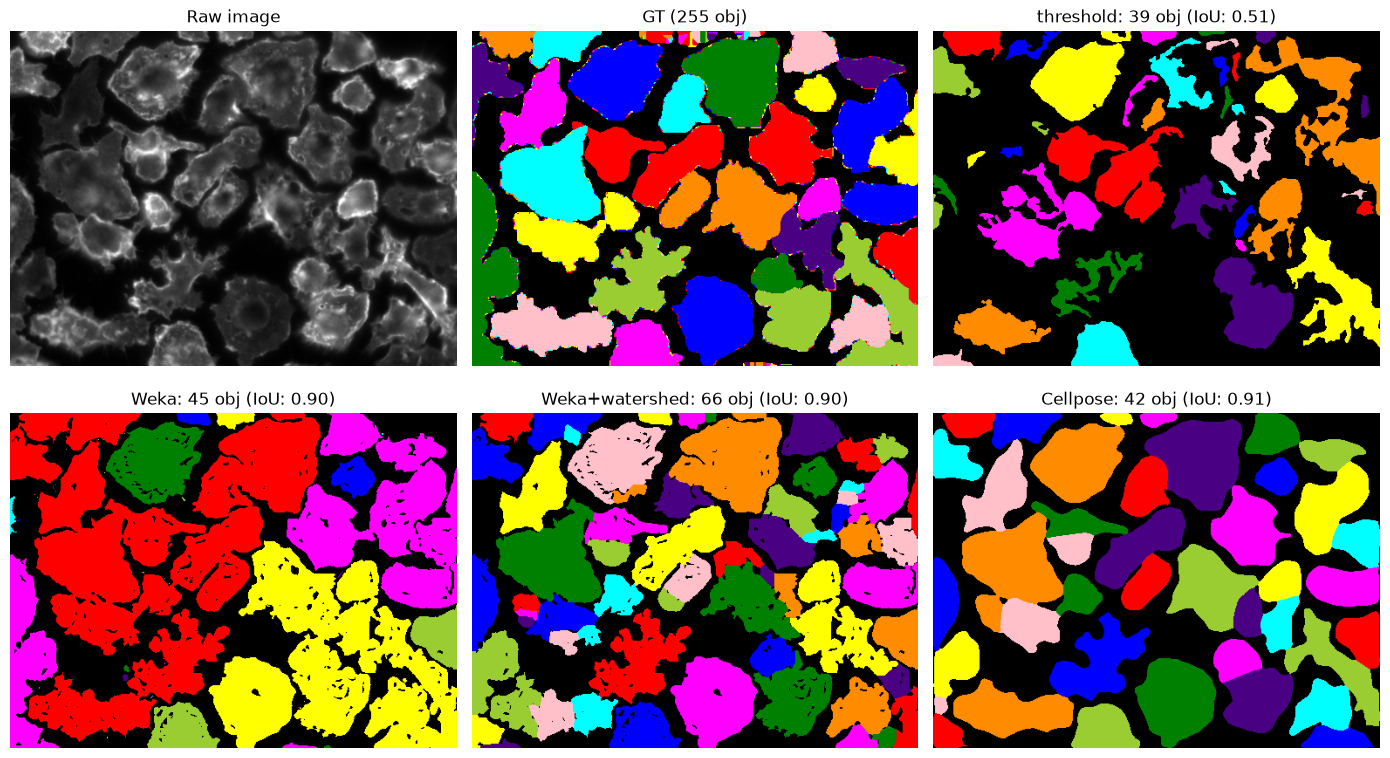

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axs = axes.flatten()

show(image, title="Raw image", ax=axs[0])
axs[1].imshow(label2rgb(truth, bg_label=0)), axs[1].axis("off"), axs[1].set_title(f"GT ({truth.max()} obj)")

for ax, (name, res) in zip(axs[2:], results.items()):
    ax.imshow(label2rgb(res, bg_label=0)), ax.axis("off")
    ax.set_title(f"{name}: {res.max()} obj (IoU: {iou(res, truth):.2f})")
[ax.axis("off") for ax in axs[2 + len(results):]]
plt.tight_layout()
plt.show()

## 4. Matching objects instead of pixels

To ask object-level questions we have to decide when a predicted object *is* a
particular real object. The standard rule: pair each prediction with the
reference object it overlaps most, and accept the pairing if their IoU clears a
threshold: conventionally **0.5**.

Every prediction and every reference object then falls into one of three groups:

- **true positive**: a prediction matched to a reference object
- **false positive**: a prediction matched to nothing (invented)
- **false negative**: a reference object nothing matched (missed)

* **Precision** (Exactness): The ratio of correctly predicted positive pixels to the total predicted positive pixels. It answers: *Of all pixels the model predicted as positive, how many were actually correct?*
  $Precision = \frac{TP}{TP + FP}$

* **Recall** (Sensitivity / Completeness): The ratio of correctly predicted positive pixels to all pixels in the actual ground truth. It answers: *Of all actual positive pixels, how many did the model find?*
  $Recall = \frac{TP}{TP + FN}$

* **F1-Score**: The harmonic mean of Precision and Recall, providing a balance between the two. In image segmentation, the F1-Score is mathematically identical to the **Dice Coefficient** that we seen before.
  $F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall} = \frac{2TP}{2TP + FP + FN}$

An F1-score near 1 means near-perfect balance with high accuracy and completeness, while a value near 0 means poor performance due to massive missed areas or excessive false alarms.


In [21]:
def match_objects(prediction, truth, min_iou=0.5):
    """Greedily pair predicted objects with ground-truth objects by IoU.

    Returns (true positives, false positives, false negatives).
    """
    matched_truth = set()
    true_positives = 0

    for p in range(1, prediction.max() + 1):
        predicted = prediction == p
        if not predicted.any():
            continue

        # Only ground-truth objects that actually touch this prediction can win.
        best_score, best_id = 0.0, None
        for t in np.unique(truth[predicted]):
            if t == 0:
                continue
            score = iou(predicted, truth == t)
            if score > best_score:
                best_score, best_id = score, t

        if best_score >= min_iou and best_id not in matched_truth:
            true_positives += 1
            matched_truth.add(best_id)

    false_positives = prediction.max() - true_positives
    false_negatives = truth.max() - true_positives
    return true_positives, false_positives, false_negatives

method              IoU   Dice |   TP   FP   FN |   prec  recall     F1
-----------------------------------------------------------------------
threshold         0.506  0.672 |    7   32  248 |  0.179   0.027  0.048
Weka              0.905  0.950 |    6   39  249 |  0.133   0.024  0.040
Weka+watershed    0.904  0.950 |   27   39  228 |  0.409   0.106  0.168
Cellpose          0.915  0.955 |   30   12  225 |  0.714   0.118  0.202


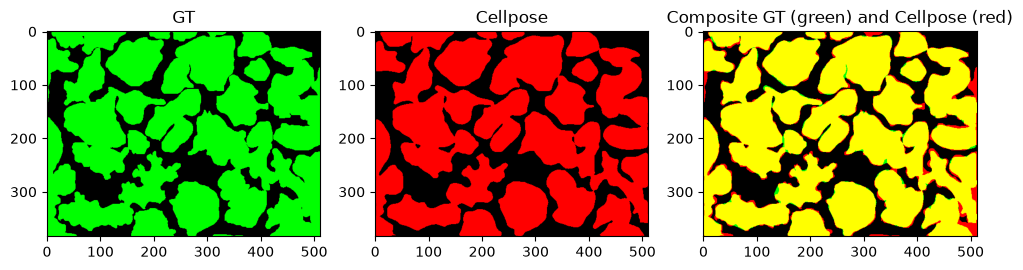

In [22]:
def scores(tp, fp, fn):
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return precision, recall, f1


header = f"{'method':16s} {'IoU':>6s} {'Dice':>6s} | {'TP':>4s} {'FP':>4s} {'FN':>4s} | {'prec':>6s} {'recall':>7s} {'F1':>6s}"
print(header)
print("-" * len(header))
for name, result in results.items():
    tp, fp, fn = match_objects(result, truth)
    precision, recall, f1 = scores(tp, fp, fn)
    print(f"{name:16s} {iou(result, truth):6.3f} {dice(result, truth):6.3f} | "
          f"{tp:4d} {fp:4d} {fn:4d} | {precision:6.3f} {recall:7.3f} {f1:6.3f}")

fig, axs = plt.subplots(1, 3, figsize=(12, 12))
normalized_gt = (truth > 0).astype(np.uint8)
normalized_cp = (results["Cellpose"] > 0).astype(np.uint8)
axs[0].imshow(make_single_rgb(normalized_gt, 'green'))
axs[0].set_title("GT")
axs[1].imshow(make_single_rgb(normalized_cp, 'red'))
axs[1].set_title("Cellpose")
axs[2].imshow(make_composite_rgb(normalized_gt, normalized_cp))
axs[2].set_title("Composite GT (green) and Cellpose (red)");

### Read the two Weka rows against each other

This is the pair to study.

**Their pixel scores are almost identical**: IoU 0.878 and 0.80, Dice 0.935 and 0.936. That
is not a coincidence: a watershed only redraws boundaries *inside* a binary image it was
handed, so essentially the same pixels are called "cell" either way.

**Their object scores are not close at all.** F1 goes from 0.058 to 0.290, and true
positives from 10 to 29. Splitting the merged blobs turned nine cells that no
metric could credit into nine correctly identified ones.

So the same segmentation, by one family of measure, did not change at all.
**The two families are answering different questions**,
and a paper reporting only Dice would show no improvement whatsoever here.

The single point to take from this notebook: **the metric has to match the
question being asked.** For total stained area, a pixel score is right. For
counting cells, or measuring anything per cell, object-level matching is
required, and a good Dice will quietly mislead.

The other rows are worth reading too:

- **Threshold**: precision 0.146, recall 0.342: it both invents and misses, which
  is what "89 objects for 38 cells, only 13 of them right" looks like.
- **Cellpose**: recall 0.895 with precision 0.654. It found 34 of the 38 annotated
  cells and missed one.

## 5. When the ground truth is wrong

In [23]:
# Cellpose's false positives: are they mistakes, or unannotated cells?
nuclei_truth = tifffile.imread(DATA / "bbbc020" / "gt" / "jw-24h 2_c5 [1].tif")

print("annotated nuclei :", nuclei_truth.max())
print("annotated cells  :", truth.max())
print("Cellpose objects :", cellpose_labels.max())

annotated nuclei : 255
annotated cells  : 255
Cellpose objects : 42


There are less annotated **nuclei** than annotated **cells**.

The dataset it is not perfect, and a handful of Cellpose's false positives
are real cells that were split. Its precision of 0.65 is
therefore a *floor*, not an estimate: the metric has no way to credit a correct
detection of an unlabelled cell.

```{warning}
Ground truth is not truth. It is one person's annotation, made with finite time
and a particular purpose. Before trusting any score, look at what was annotated: 
here, `jw-24h 2_c*` is the only field in which every cell was outlined, which is why
the exercise below uses it.
```

This cuts both ways in practice. A published benchmark number is only meaningful
relative to the annotations it was computed against, and a model that scores
worse than another on one dataset may simply disagree with that dataset's
conventions.

## 6. Choosing the matching threshold

In [24]:
thresholds = [0.3, 0.5, 0.7, 0.9]
print(f"{'method':16s}" + "".join(f"{t:>10.1f}" for t in thresholds))
print("-" * (16 + 10 * len(thresholds)))
for name, result in results.items():
    row = f"{name:16s}"
    for t in thresholds:
        tp, fp, fn = match_objects(result, truth, min_iou=t)
        row += f"{scores(tp, fp, fn)[2]:10.3f}"
    print(row)
print("\n(F1 at each matching IoU threshold)")

method                 0.3       0.5       0.7       0.9
--------------------------------------------------------
threshold            0.102     0.048     0.027     0.000
Weka                 0.047     0.040     0.033     0.007
Weka+watershed       0.206     0.168     0.106     0.000
Cellpose             0.222     0.202     0.189     0.047

(F1 at each matching IoU threshold)


The 0.5 convention is exactly that: a convention. A stricter threshold demands
better-fitting outlines and every score falls.

Notice how differently they fall. Cellpose still manages 0.6 at a demanding 0.7,
whereas plain Weka is flat at 0.052 until it collapses to zero: its handful of
matches are blobs that happen to contain one dominant cell, and nothing about
tightening the criterion can create matches for the cells that were merged away.

When an F1 is reported, **the matching threshold should be stated with it**. It is
not comparable otherwise, and papers do vary.

## Recap

| metric | measures | use it when |
|---|---|---|
| IoU / Jaccard | pixel overlap | area or extent is what matters |
| Dice | pixel overlap, weighted to intersection | as above; always reads higher than IoU |
| precision | how many of the detected objects are real | false positives are costly |
| recall | how many real objects were found | misses are costly |
| F1 | the balance of the two | general-purpose object-level score |

And the three habits worth keeping:

1. Report a pixel score **and** an object score. They can disagree completely.
2. State which metric and which matching threshold were used.
3. Look at what the ground truth actually contains before believing any of it.

Next: `05_features`, where the segmentation stops being the goal and becomes the
starting point for measuring the objects that were found.